# 06. XGBoost Model Validation

This notebook validates the predictive component of the SupplyPrescript system using XGBoost. The model is trained using the cleaned supply-chain dataset and compared with the previously developed predictive model.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path("../data/processed/supply_chain_cleaned.csv")

df = pd.read_csv(data_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Loaded Successfully
Shape: (113097, 18)

Columns:
['warehouse_inventory_level', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation', 'product_id', 'supplier_id', 'supplier_country']


,warehouse_inventory_level,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,cargo_condition_status,route_risk_level,customs_clearance_time,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,product_id,supplier_id,supplier_country
0,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S1,Greece
1,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S2,South Korea
2,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S3,Ethiopia
3,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,High Risk,8.175281,P0857,P0857_S1,Iran
4,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,High Risk,8.175281,P0857,P0857_S2,Guatemala


In [2]:
print("Dataset Information:")
print(df.info())

print("\nUnique values for possible target columns:")

for col in df.columns:
    if df[col].nunique() <= 15:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113097 entries, 0 to 113096
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   warehouse_inventory_level        113097 non-null  float64
 1   handling_equipment_availability  113097 non-null  float64
 2   order_fulfillment_status         113097 non-null  float64
 3   weather_condition_severity       113097 non-null  float64
 4   shipping_costs                   113097 non-null  float64
 5   supplier_reliability_score       113097 non-null  float64
 6   lead_time_days                   113097 non-null  float64
 7   historical_demand                113097 non-null  float64
 8   cargo_condition_status           113097 non-null  float64
 9   route_risk_level                 113097 non-null  float64
 10  customs_clearance_time           113097 non-null  float64
 11  disruption_likelihood_score      113097 non-

In [3]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing Values:")
print(missing_values)

Missing Values:
Series([], dtype: int64)


In [4]:
print(df.dtypes)

warehouse_inventory_level          float64
handling_equipment_availability    float64
order_fulfillment_status           float64
weather_condition_severity         float64
shipping_costs                     float64
supplier_reliability_score         float64
lead_time_days                     float64
historical_demand                  float64
cargo_condition_status             float64
route_risk_level                   float64
customs_clearance_time             float64
disruption_likelihood_score        float64
delay_probability                  float64
risk_classification                 object
delivery_time_deviation            float64
product_id                          object
supplier_id                         object
supplier_country                    object
dtype: object


## 5. Feature and Target Preparation

The target variable is `risk_classification`, representing the predicted supply-chain risk level as Low Risk, Moderate Risk, or High Risk.

Potential leakage variables and identifier columns are excluded from the model features.

In [5]:
target = "risk_classification"

# Features used for predictive modelling
feature_columns = [
    "warehouse_inventory_level",
    "handling_equipment_availability",
    "weather_condition_severity",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "route_risk_level",
    "customs_clearance_time",
    "supplier_country"
]

X = df[feature_columns].copy()
y = df[target].copy()

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
for col in X.columns:
    print("-", col)

print("\nTarget Distribution:")
print(y.value_counts())

Feature Matrix Shape: (113097, 10)
Target Shape: (113097,)

Features:
- warehouse_inventory_level
- handling_equipment_availability
- weather_condition_severity
- shipping_costs
- supplier_reliability_score
- lead_time_days
- historical_demand
- route_risk_level
- customs_clearance_time
- supplier_country

Target Distribution:
risk_classification
High Risk        84368
Moderate Risk    17783
Low Risk         10946
Name: count, dtype: int64


## 6. Target Encoding

The categorical risk classes are converted into numerical labels so that they can be used by the XGBoost classifier.

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Target Classes:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

print("\nEncoded Target Distribution:")
print(pd.Series(y_encoded).value_counts().sort_index())

Target Classes:
0 = High Risk
1 = Low Risk
2 = Moderate Risk

Encoded Target Distribution:
0    84368
1    10946
2    17783
Name: count, dtype: int64


## 7. Train-Test Split

The dataset is divided into 80% training data and 20% testing data. Stratified sampling is used to preserve the original risk-class distribution.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (90477, 10)
Testing Features: (22620, 10)
Training Target: (90477,)
Testing Target: (22620,)


## 8. Feature Preprocessing

Numerical variables are passed directly to the model, while the categorical `supplier_country` feature is transformed using One-Hot Encoding.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["supplier_country"]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Numerical Features:", len(numeric_features))
print("Categorical Features:", categorical_features)

Numerical Features: 9
Categorical Features: ['supplier_country']


In [9]:
try:
    import xgboost as xgb
    print("XGBoost Version:", xgb.__version__)
    print("XGBoost is installed successfully.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost Version: 3.0.4
XGBoost is installed successfully.


## 10. Build XGBoost Classification Pipeline

The preprocessing transformer and XGBoost classifier are combined into a single machine learning pipeline. The model predicts the supply-chain risk category for each record.

In [10]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

print("XGBoost Pipeline Created Successfully")

XGBoost Pipeline Created Successfully


## 11. Train XGBoost Model

In [11]:
xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost Model Training Completed Successfully")

XGBoost Model Training Completed Successfully


## 12. Generate Predictions

In [12]:
y_pred = xgb_pipeline.predict(X_test)

y_pred_proba = xgb_pipeline.predict_proba(X_test)

print("Predictions Generated Successfully")
print("Predicted Records:", len(y_pred))
print("Probability Matrix Shape:", y_pred_proba.shape)

Predictions Generated Successfully
Predicted Records: 22620
Probability Matrix Shape: (22620, 3)


## 13. Evaluate XGBoost Model

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

print("=" * 60)
print("XGBOOST MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")

XGBOOST MODEL PERFORMANCE
Accuracy          : 0.7480
Balanced Accuracy : 0.3383
Precision         : 0.8116
Recall            : 0.7480
F1 Score          : 0.6421


## 14. Classification Report

In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

               precision    recall  f1-score   support

    High Risk       0.75      1.00      0.86     16874
     Low Risk       1.00      0.01      0.01      2189
Moderate Risk       1.00      0.01      0.02      3557

     accuracy                           0.75     22620
    macro avg       0.92      0.34      0.30     22620
 weighted avg       0.81      0.75      0.64     22620



## 15. Confusion Matrix

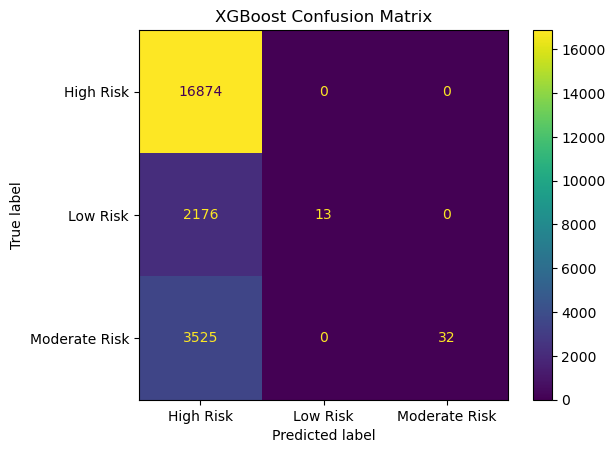

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

## 16. Handle Class Imbalance Using Class Weights

The dataset contains a significantly larger number of High Risk records compared with Low Risk and Moderate Risk records. Class weights are therefore applied during XGBoost training so that minority risk classes receive greater importance.

In [17]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample Weights Generated Successfully")
print("Number of Weights:", len(sample_weights))

for class_id, class_name in enumerate(label_encoder.classes_):
    mask = y_train == class_id
    
    print(
        class_name,
        "Average Weight:",
        round(sample_weights[mask].mean(), 4)
    )

Sample Weights Generated Successfully
Number of Weights: 90477
High Risk Average Weight: 0.4468
Low Risk Average Weight: 3.444
Moderate Risk Average Weight: 2.12


## 17. Retrain XGBoost with Class Balancing

In [18]:
balanced_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="mlogloss"
        ))
    ]
)

balanced_xgb_pipeline.fit(
    X_train,
    y_train,
    classifier__sample_weight=sample_weights
)

print("Balanced XGBoost Model Training Completed Successfully")

Balanced XGBoost Model Training Completed Successfully


## 18. Evaluate Balanced XGBoost Model

In [19]:
balanced_y_pred = balanced_xgb_pipeline.predict(X_test)

balanced_accuracy_normal = accuracy_score(
    y_test,
    balanced_y_pred
)

balanced_accuracy_metric = balanced_accuracy_score(
    y_test,
    balanced_y_pred
)

balanced_precision = precision_score(
    y_test,
    balanced_y_pred,
    average="weighted",
    zero_division=0
)

balanced_recall = recall_score(
    y_test,
    balanced_y_pred,
    average="weighted",
    zero_division=0
)

balanced_f1 = f1_score(
    y_test,
    balanced_y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("BALANCED XGBOOST MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy          : {balanced_accuracy_normal:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_metric:.4f}")
print(f"Precision         : {balanced_precision:.4f}")
print(f"Recall            : {balanced_recall:.4f}")
print(f"F1 Score          : {balanced_f1:.4f}")

BALANCED XGBOOST MODEL PERFORMANCE
Accuracy          : 0.6932
Balanced Accuracy : 0.7033
Precision         : 0.7843
Recall            : 0.6932
F1 Score          : 0.7173


In [20]:
print(
    classification_report(
        y_test,
        balanced_y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

               precision    recall  f1-score   support

    High Risk       0.91      0.69      0.78     16874
     Low Risk       0.37      0.71      0.49      2189
Moderate Risk       0.45      0.71      0.55      3557

     accuracy                           0.69     22620
    macro avg       0.58      0.70      0.61     22620
 weighted avg       0.78      0.69      0.72     22620



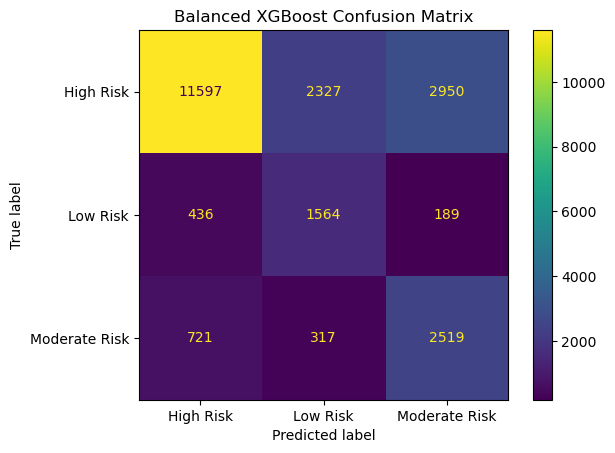

In [21]:
balanced_cm = confusion_matrix(
    y_test,
    balanced_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=balanced_cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Balanced XGBoost Confusion Matrix")
plt.show()

## 20. Original vs Balanced XGBoost Comparison

The original and class-balanced XGBoost models are compared to determine which model provides more reliable performance across all supply-chain risk categories.

In [22]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    
    "Original XGBoost": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ],
    
    "Balanced XGBoost": [
        balanced_accuracy_normal,
        balanced_accuracy_metric,
        balanced_precision,
        balanced_recall,
        balanced_f1
    ]
})

comparison_df["Improvement"] = (
    comparison_df["Balanced XGBoost"] -
    comparison_df["Original XGBoost"]
)

comparison_df.round(4)

,Metric,Original XGBoost,Balanced XGBoost,Improvement
0,Accuracy,0.7480,0.6932,-0.0548
1,Balanced Accuracy,0.3383,0.7033,0.3650
2,Precision,0.8116,0.7843,-0.0273
3,Recall,0.7480,0.6932,-0.0548
4,F1 Score,0.6421,0.7173,0.0752


## 21. Final Model Selection

Although the original XGBoost model achieved higher overall accuracy, it performed poorly on minority risk classes. The class-balanced XGBoost model provides substantially better balanced accuracy and minority-class recall. Therefore, the Balanced XGBoost model is selected as the final predictive model.

In [23]:
final_model = balanced_xgb_pipeline

print("=" * 65)
print("FINAL MODEL SELECTION")
print("=" * 65)

print("Selected Model       : Balanced XGBoost")
print(f"Accuracy             : {balanced_accuracy_normal:.4f}")
print(f"Balanced Accuracy    : {balanced_accuracy_metric:.4f}")
print(f"Weighted F1 Score    : {balanced_f1:.4f}")

print("\nReason:")
print("Balanced XGBoost provides significantly better")
print("performance across High, Moderate and Low Risk classes.")

FINAL MODEL SELECTION
Selected Model       : Balanced XGBoost
Accuracy             : 0.6932
Balanced Accuracy    : 0.7033
Weighted F1 Score    : 0.7173

Reason:
Balanced XGBoost provides significantly better
performance across High, Moderate and Low Risk classes.


## 22. Export Model Validation Results

In [24]:
from pathlib import Path

validation_results = pd.DataFrame({
    "model": [
        "Original XGBoost",
        "Balanced XGBoost"
    ],
    "accuracy": [
        accuracy,
        balanced_accuracy_normal
    ],
    "balanced_accuracy": [
        balanced_accuracy,
        balanced_accuracy_metric
    ],
    "precision": [
        precision,
        balanced_precision
    ],
    "recall": [
        recall,
        balanced_recall
    ],
    "f1_score": [
        f1,
        balanced_f1
    ]
})

output_path = Path("../outputs/xgboost_model_validation.csv")

validation_results.to_csv(
    output_path,
    index=False
)

print("Model Validation Results Exported Successfully")
print("File:", output_path)

validation_results.round(4)

Model Validation Results Exported Successfully
File: ..\outputs\xgboost_model_validation.csv


,model,accuracy,balanced_accuracy,precision,recall,f1_score
0,Original XGBoost,0.7480,0.3383,0.8116,0.7480,0.6421
1,Balanced XGBoost,0.6932,0.7033,0.7843,0.6932,0.7173
